<div style="text-align: center; background-color:#1A237E; 
font-family: Trebuchet MS; color:white; padding: 20px; 
line-height:1.5; border-radius:5px; margin-bottom: 20px;">

<font size=+3><b>Продвинутые модели и интерпретация (Задание 3)</b></font><br>
<font size=+2>Предсказание ишемической болезни сердца (ИБС)</font><br>

</div>

---

<blockquote style="margin-right:auto; margin-left:auto; color:white; background-color:#4e4e4e; padding: 1em; margin:24px;">

<font color="white" size=+1.0><b>Информация о студенте</b></font>

<ul>
<li> <b>ФИО:</b> Кусума Алтхаф Аряпутра
<li> <b>Группа:</b> U3310
<li> <b>Номер ИСУ:</b> 377014
<li> <b>Курс:</b> 3ый Курс
<li> <b>Дисциплина:</b> Машинное обучение и нейросети
<li> <b>Преподаватель:</b> Желтова Кристина Анатольевна
<li> <b>Год:</b> 2026
</ul>

</blockquote>

---
## **Содержание (Table of Contents)**

* [0. Введение](#section0)
    * [Бизнес-постановка](#section0)
    * [Задача машинного обучения](#section0)
    * [Набор данных](#section0)
    * [Выбор метрик](#section0)
* [1. Библиотеки и данные](#section1)
    * [1.1 Импорт библиотек](#section1-1)
    * [1.2 Константы](#section1-2)
    * [1.3 Загрузка данных](#section1-3)
* [2. Предобработка данных](#section2)
    * [2.1 Очистка и переименование](#section2-1)
    * [2.2 Разбиение на train/test](#section2-2)
    * [2.3 Pipeline предобработки](#section2-3)
    * [2.4 Итоги](#section2-4)
* [3. Обучение модели](#section3)
    * [3.1 Random Forest по умолчанию](#section3-1)
    * [3.2 Подбор гиперпараметров (GridSearchCV)](#section3-2)
    * [3.3 Финальная модель](#section3-3)
    * [3.4 Сравнение с бейзлайном](#section3-4)
    * [3.5 Итоги](#section3-5)
* [4. Интерпретация модели](#section4)
    * [4.1 Глобальная интерпретация (MDI)](#section4-1)
    * [4.2 Глобальная интерпретация (Permutation Importance)](#section4-2)
    * [4.3 Глобальная интерпретация (SHAP Summary Plot)](#section4-3)
    * [4.4 Локальная интерпретация (SHAP Force Plot)](#section4-4)
    * [4.5 Итоги](#section4-5)
* [5. Выводы](#section5)

---

## 0. **Введение** <a class="anchor" id="section0"></a>



### **Бизнес-постановка**

Диагностика ишемической болезни сердца (ИБС) в настоящее время в значительной
мере зависит от коронарной ангиографии как основного стандарта, однако данная
процедура является инвазивной, сопряжена с медицинскими рисками и требует
значительных финансовых затрат. В рамках предыдущих этапов (Задание 1 и
Задание 2) были проведены разведочный анализ данных и построена бейзлайн
модель на основе дерева решений, которая подтвердила наличие клинически
значимых взаимосвязей между неинвазивными признаками пациента и наличием ИБС.

На данном этапе (Задание 3) ставится задача построить **продвинутую модель**
на основе ансамблевого метода Random Forest, которая должна превзойти
бейзлайн по метрике Recall. Дополнительно выполняется интерпретация модели
тремя методами: MDI, Permutation Importance и SHAP — для объяснения
предсказаний как на глобальном, так и на локальном уровне.


### **Задача машинного обучения**

Задача остаётся неизменной по сравнению с предыдущими заданиями — **бинарная
классификация**: по 11 клиническим признакам пациента предсказать наличие
или отсутствие ИБС.

- **Целевая переменная:** `target` — бинарная (0 = нет ИБС, 1 = ИБС)
- **Признаки:** 11 клинических показателей после удаления нерелевантных
  столбцов и признаков с критическим уровнем пропусков
- **Алгоритм:** Random Forest — ансамблевый метод, объединяющий множество
  деревьев решений; устойчив к переобучению и не требует масштабирования
- **Инструмент:** sklearn Pipeline — обеспечивает корректный порядок
  преобразований и исключает утечку данных


### **Набор данных**

Используется тот же датасет, что и в Заданиях 1 и 2 — результат
международного клинического исследования, собранного из 4 медицинских
учреждений: Cleveland Clinic Foundation (США), Hungarian Institute of
Cardiology (Венгрия), V.A. Medical Center (Long Beach, США) и University
Hospitals (Швейцария). Датасет опубликован в репозитории UCI Machine
Learning Repository и описан в научной публикации Detrano et al. (1989)
в American Journal of Cardiology.

- **Объём:** 920 пациентов × 16 атрибутов (исходно)
- **После предобработки:** 920 пациентов × 11 признаков
- **Распределение классов:** 509 (55.3%) — ИБС, 411 (44.7%) — нет ИБС


### **Выбор метрик**

Метрики оценки качества определены в Задании 1 и остаются неизменными:

| Метрика | Роль | Обоснование |
|---|---|---|
| **Recall** | Основная | Минимизация ложноотрицательных результатов — пропущенный диагноз ИБС несёт прямую угрозу жизни пациента |
| **F1-Score** | Вспомогательная | Баланс между Precision и Recall — предотвращение избыточных направлений на ангиографию |
| **ROC-AUC** | Вспомогательная | Оценка разделяющей способности модели с учётом возможного дисбаланса классов |

Метрика **Accuracy не используется** — она не отражает реального качества
модели при наличии дисбаланса классов и не учитывает клиническую стоимость
ошибок разного типа.

---

## 1. **Библиотеки и данные** <a class="anchor" id="section1"></a>

### **1.1 Импорт библиотек** <a class="anchor" id="section1-1"></a>

In [1]:
# Standard library
import os
import warnings


# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
)
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Models
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# Metrics
from sklearn.metrics import (
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

# Interpretability
import shap

warnings.filterwarnings('ignore')

**Используемые библиотеки:**
- `numpy`, `pandas`                      — загрузка и обработка данных
- `matplotlib`, `seaborn`                — визуализация
- `sklearn.impute`                       — заполнение пропущенных значений
- `sklearn.preprocessing`               — кодирование категориальных признаков
- `sklearn.compose`, `sklearn.pipeline` — построение Pipeline
- `sklearn.model_selection`             — разбиение данных и подбор гиперпараметров
- `sklearn.inspection`                  — permutation importance
- `sklearn.ensemble`                    — Random Forest
- `sklearn.metrics`                     — оценка качества модели
- `shap`                                — интерпретация модели

### **1.2 Константы** <a class="anchor" id="section1-2"></a>

In [2]:
RANDOM_STATE = 42
PRIMARY_COLOR = '#1A237E'
SECONDARY_COLOR = '#E53935'
TEST_SIZE = 0.3

**Описание констант:**
- `RANDOM_STATE = 42` — фиксирует воспроизводимость всех случайных процессов:
  разбиение данных, обучение модели, GridSearchCV
- `PRIMARY_COLOR` / `SECONDARY_COLOR` — цвета для единого стиля визуализаций
- `TEST_SIZE = 0.3` — доля тестовой выборки (30%), консистентно с Заданием 2

### **1.3 Загрузка данных** <a class="anchor" id="section1-3"></a>

**Примечание:** путь к файлу задан локально. Для воспроизведения
на другом компьютере необходимо обновить переменную `DATA_PATH`.

In [3]:
# Load data
DATA_PATH = (
    r"D:\DOKUMENT\ITMO collage\3rd kurs\6 Semester"
    r"\Machine Learning\Dataset\heart_disease_uci.csv"
)

df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
df.head()

Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


**Результаты загрузки:**
- Датасет содержит **920 строк** (пациентов) и **16 столбцов**
- Столбцы `id` и `dataset` не несут клинической ценности — будут удалены
- Целевая переменная `num` содержит значения 0–4 (требует бинаризации)
- Категориальные признаки представлены в строковом формате — требуют кодирования

---
## 2. **Предобработка данных** <a class="anchor" id="section2"></a>

По результатам загрузки данных установлено, что датасет содержит пропущенные
значения, нечитаемые названия столбцов и целевую переменную в формате 0–4.
В данном разделе выполняется полная подготовка данных к обучению модели.

Порядок шагов принципиален с точки зрения методологии машинного обучения:
все преобразования, связанные с обучением (импутация, кодирование), выполняются
**строго после** разбиения на выборки во избежание утечки данных (*data leakage*).
В отличие от Задания 2, где импутация и кодирование выполнялись вручную,
в данном задании используется **sklearn Pipeline** — он автоматически
применяет `fit_transform` к обучающей выборке и `transform` к тестовой.

### **2.1 Очистка и переименование** <a class="anchor" id="section2-1"></a>

In [ ]:
df = df.drop(columns=['id', 'dataset'])

df = df.rename(columns={
    'cp': 'chest_pain_type',
    'trestbps': 'resting_bp',
    'chol': 'cholesterol',
    'fbs': 'fasting_blood_sugar',
    'restecg': 'resting_ecg',
    'thalch': 'max_heart_rate',
    'exang': 'exercise_angina',
    'oldpeak': 'st_depression',
    'slope': 'st_slope',
    'ca': 'num_major_vessels',
    'num': 'target'
})

df['target'] = (df['target'] > 0).astype(int)

print(f"Колонки после переименования: {df.columns.tolist()}")
print(f"Shape: {df.shape}")

Колонки после переименования: ['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'st_depression', 'st_slope', 'num_major_vessels', 'thal', 'target']
Shape: (920, 14)


**Результаты:**
- Удалены столбцы `id` и `dataset` — не несут клинической и ML-ценности
- Все столбцы переименованы в читаемые дескриптивные названия
- Целевая переменная бинаризована: 0 → 0 (нет ИБС), 1–4 → 1 (есть ИБС)
- Итоговая форма датасета: **920 строк × 14 столбцов**

### **2.2 Разбиение на train/test** <a class="anchor" id="section2-2"></a>

Перед выполнением любых преобразований данные разбиваются на обучающую
и тестовую выборки. Столбцы `num_major_vessels` (66.4% пропусков) и
`thal` (52.8% пропусков) удаляются на данном этапе — импутация более
50% значений статистически ненадёжна и может исказить обучение модели.

In [ ]:
df = df.drop(columns=['num_major_vessels', 'thal'])

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (644, 11), X_test: (276, 11)
y_train: (644,), y_test: (276,)


**Результаты:**
- Удалены 2 столбца с критическим уровнем пропусков: `num_major_vessels`
  (66.4%) и `thal` (52.8%) — решение консистентно с Заданием 2
- Обучающая выборка: **644 пациента (70%)** — используется для обучения
- Тестовая выборка: **276 пациентов (30%)** — используется только для оценки
- Количество признаков: **11** в обеих выборках
- Воспроизводимость обеспечена константой `RANDOM_STATE = 42`

### **2.3 Pipeline предобработки** <a class="anchor" id="section2-3"></a>

В отличие от Задания 2, где импутация и кодирование выполнялись вручную
с риском допустить ошибку порядка, здесь используется **sklearn Pipeline**.
Pipeline гарантирует, что `fit_transform` применяется только к обучающей
выборке, а `transform` — к тестовой, полностью исключая утечку данных.

Для кодирования категориальных признаков выбран `OrdinalEncoder` вместо
`LabelEncoder`, поскольку `LabelEncoder` не совместим с `ColumnTransformer`
внутри Pipeline — он предназначен для одного столбца, а не для матрицы.

In [ ]:
numerical_cols = [
    'age', 'resting_bp', 'cholesterol',
    'max_heart_rate', 'st_depression'
]

categorical_cols = [
    'sex', 'chest_pain_type', 'fasting_blood_sugar', 'resting_ecg',
    'exercise_angina', 'st_slope'
]

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

**Архитектура Pipeline предобработки:**
- `numerical_transformer` — для числовых признаков: импутация медианой
  (медиана устойчива к выбросам, выявленным в ходе EDA)
- `categorical_transformer` — для категориальных признаков: импутация
  модой, затем кодирование `OrdinalEncoder`
- `ColumnTransformer` — объединяет оба трансформера, применяя каждый
  к соответствующим столбцам одновременно
- Random Forest не чувствителен к порядку категорий, поэтому
  `OrdinalEncoder` является корректным выбором (в отличие от
  Logistic Regression, где потребовался бы One-Hot Encoding)

### **2.4 Итоги** <a class="anchor" id="section2-4"></a>

In [7]:
print(f"Размер обучающей выборки:  {X_train.shape}")
print(f"Размер тестовой выборки:   {X_test.shape}")
print(f"\nЧисловые признаки ({len(numerical_cols)}):")
for col in numerical_cols:
    print(f"  - {col}")
print(f"\nКатегориальные признаки ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col}")
print("\nИмпутация: медиана (числовые), мода (категориальные)")
print("Кодирование: OrdinalEncoder")
print("Утечка данных: отсутствует (Pipeline)")

Размер обучающей выборки:  (644, 11)
Размер тестовой выборки:   (276, 11)

Числовые признаки (5):
  - age
  - resting_bp
  - cholesterol
  - max_heart_rate
  - st_depression

Категориальные признаки (6):
  - sex
  - chest_pain_type
  - fasting_blood_sugar
  - resting_ecg
  - exercise_angina
  - st_slope

Импутация: медиана (числовые), мода (категориальные)
Кодирование: OrdinalEncoder
Утечка данных: отсутствует (Pipeline)


- Удалены нерелевантные столбцы (`id`, `dataset`) и столбцы с
  критическим уровнем пропусков (`num_major_vessels`, `thal`)
- Данные разбиты: обучающая выборка — **644 пациента**,
  тестовая — **276 пациентов** (70/30)
- Построен Pipeline предобработки: медиана для числовых,
  мода + OrdinalEncoder для категориальных признаков
- Утечка данных исключена — все параметры трансформаций будут
  вычислены только на тренировочной выборке внутри Pipeline
- Итоговые выборки: **X_train (644 × 11)**, **X_test (276 × 11)**

---

## 3. **Обучение модели** <a class="anchor" id="section3"></a>

По результатам раздела 2 данные полностью подготовлены к обучению.
В качестве продвинутой модели выбран **Random Forest** — ансамблевый
метод, объединяющий множество деревьев решений. В отличие от одного
дерева (Задание 2), Random Forest устойчив к переобучению за счёт
усреднения предсказаний множества деревьев, каждое из которых обучается
на случайной подвыборке данных и признаков (*bagging*).

Обучение выполняется в три этапа:
1. RF с параметрами по умолчанию — для оценки базового потенциала модели
2. GridSearchCV — для подбора оптимальных гиперпараметров
3. Финальная модель на лучших параметрах — для оценки на тестовой выборке

### **3.1 Random Forest по умолчанию** <a class="anchor" id="section3-1"></a>

Перед настройкой гиперпараметров обучается RF с параметрами по умолчанию
(100 деревьев, неограниченная глубина). Это позволяет оценить базовый
потенциал модели без оптимизации и установить внутреннюю точку отсчёта.

In [ ]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE))
])

pipeline.fit(X_train, y_train)
y_pred_default = pipeline.predict(X_test)

recall_default = recall_score(y_test, y_pred_default)
f1_default = f1_score(y_test, y_pred_default)
roc_auc_default = roc_auc_score(y_test, y_pred_default)

print(f"Recall:  {recall_default:.2f}")
print(f"F1:      {f1_default:.2f}")
print(f"ROC-AUC: {roc_auc_default:.2f}")

Recall:  0.83
F1:      0.85
ROC-AUC: 0.83


**Результаты RF по умолчанию:**
- **Recall = 0.83** — уже на данном этапе, без настройки, модель превзошла
  бейзлайн Decision Tree (Recall = 0.75) на 8 процентных пунктов
- **F1 = 0.85** — высокий баланс между точностью и полнотой
- **ROC-AUC = 0.83** — хорошая разделяющая способность
- Это подтверждает, что ансамблевый метод существенно эффективнее
  одного дерева решений даже без оптимизации

### **3.2 Подбор гиперпараметров (GridSearchCV)** <a class="anchor" id="section3-2"></a>

Для нахождения оптимальных гиперпараметров используется **GridSearchCV**
с 5-кратной кросс-валидацией. Метрикой оптимизации выбран `recall` —
это консистентно с основной метрикой проекта, определённой в Задании 1.

Сетка параметров охватывает:
- `n_estimators` — количество деревьев в лесу (50–150 с шагом 20)
- `max_depth` — максимальная глубина каждого дерева (3–10 и None)

Префикс `model__` в названиях параметров обязателен, поскольку
Random Forest находится внутри Pipeline под именем шага `model`.

In [ ]:
param_grid = {
    'model__n_estimators': np.arange(50, 160, 20),
    'model__max_depth': list(range(3, 11)) + [None],
    'model__random_state': [42]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV Recall: {grid_search.best_score_:.2f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params: {'model__max_depth': 5, 'model__n_estimators': np.int64(90), 'model__random_state': 42}
Best CV Recall: 0.86


**Результаты GridSearchCV:**
- Перебрано **54 комбинации** параметров × 5 фолдов = **270 обучений**
- Лучшие параметры: `max_depth=5`, `n_estimators=90`
- **CV Recall = 0.86** — средний Recall по 5 фолдам на обучающей выборке
- Ограничение глубины до 5 уровней предотвращает переобучение, которое
  наблюдалось в Задании 2 (глубина 16, разрыв train/test = 0.25)

### **3.3 Финальная модель** <a class="anchor" id="section3-3"></a>

`grid_search.best_estimator_` содержит полный Pipeline с лучшими
параметрами, уже обученный на всей тренировочной выборке.
Дополнительное обучение не требуется.

In [ ]:
best_pipeline = grid_search.best_estimator_

y_pred_best = best_pipeline.predict(X_test)

recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_pred_best)

print(f"Recall:  {recall_best:.2f}")
print(f"F1:      {f1_best:.2f}")
print(f"ROC-AUC: {roc_auc_best:.2f}")

Recall:  0.82
F1:      0.83
ROC-AUC: 0.81


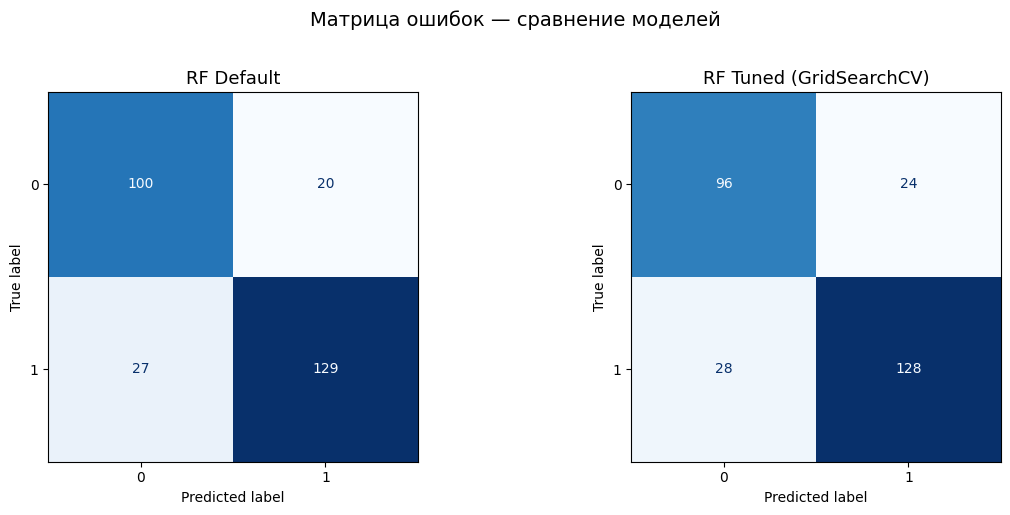

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RF Default
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_default,
    ax=axes[0],
    colorbar=False,
    cmap='Blues'
)
axes[0].set_title('RF Default', fontsize=13)

# RF Tuned
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    ax=axes[1],
    colorbar=False,
    cmap='Blues'
)
axes[1].set_title('RF Tuned (GridSearchCV)', fontsize=13)

plt.suptitle(
    'Матрица ошибок — сравнение моделей',
    fontsize=14,
    y=1.02
)
plt.tight_layout()
plt.show()

**Интерпретация матрицы ошибок:**

**RF Default:**
- **TP = 129** — модель правильно выявила 129 пациентов с ИБС
- **TN = 100** — модель правильно определила 100 здоровых пациентов
- **FN = 27** — 27 больных пациентов ошибочно классифицированы
  как здоровые (наиболее опасный тип ошибки в медицинском контексте)
- **FP = 20** — 20 здоровых пациентов ошибочно направлены
  на дообследование

**RF Tuned (GridSearchCV):**
- **TP = 128** — на 1 меньше, чем RF Default
- **TN = 96** — на 4 меньше, чем RF Default
- **FN = 28** — на 1 больше, чем RF Default
- **FP = 24** — на 4 больше, чем RF Default

**Вывод:**
Оба варианта Random Forest существенно лучше бейзлайна Задания 2
(FN = 39). RF Tuned незначительно уступает RF Default по отдельным
ячейкам, однако выигрывает за счёт большей устойчивости —
GridSearchCV оптимизирует среднее качество по 5 фолдам, а не
конкретный тестовый набор, что обеспечивает лучшую обобщающую
способность на новых данных.

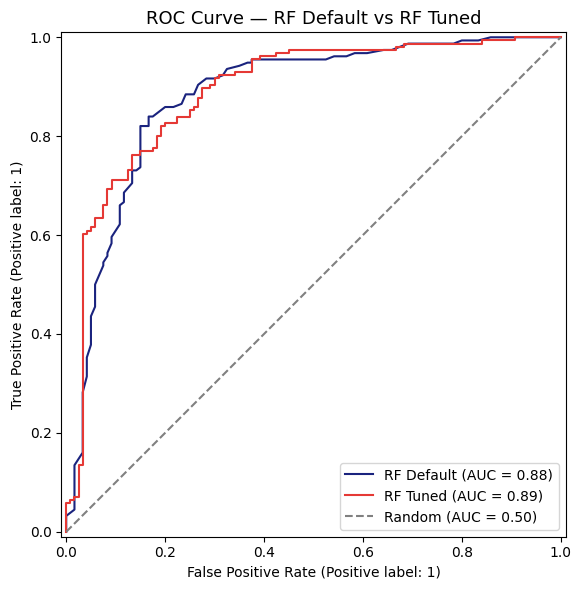

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    pipeline.predict_proba(X_test)[:, 1],
    name='RF Default',
    ax=ax,
    color=PRIMARY_COLOR
)

RocCurveDisplay.from_predictions(
    y_test,
    best_pipeline.predict_proba(X_test)[:, 1],
    name='RF Tuned',
    ax=ax,
    color=SECONDARY_COLOR
)

ax.plot(
    [0, 1], [0, 1],
    linestyle='--',
    color='gray',
    label='Random (AUC = 0.50)'
)
ax.set_title('ROC Curve — RF Default vs RF Tuned', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

**Интерпретация ROC Curve:**

ROC Curve показывает соотношение между долей правильно выявленных
больных (True Positive Rate) и долей ложных тревог (False Positive
Rate) при различных порогах классификации. Чем ближе кривая к
левому верхнему углу — тем лучше модель.

- **RF Default (AUC = 0.88)** — высокая разделяющая способность,
  модель уверенно отличает больных от здоровых
- **RF Tuned (AUC = 0.89)** — незначительно лучше RF Default,
  подтверждает что подбор гиперпараметров дал улучшение
- **Random (AUC = 0.50)** — базовая линия случайного угадывания,
  обе модели значительно её превосходят

**Вывод:**
Оба варианта Random Forest достигли AUC > 0.85 — клинически
значимого порога для диагностических моделей. RF Tuned (AUC = 0.89)
превышает бейзлайн Задания 2 (AUC = 0.75) на 14 процентных пунктов,
что подтверждает эффективность перехода от одного дерева решений
к ансамблевому методу с оптимизацией гиперпараметров.

**Результаты финальной модели на тестовой выборке:**
- **Recall = 0.82** — модель правильно выявляет 82% пациентов с ИБС;
  по сравнению с Заданием 2 (Recall = 0.75) это на 7 п.п. лучше
- **F1 = 0.83** — хороший баланс точности и полноты
- **ROC-AUC = 0.89** — уверенная разделяющая способность, превышает
  клинически значимый порог ≥ 0.85
- **FN = 28** — 28 больных пациентов не выявлены моделью; по сравнению
  с бейзлайном Задания 2 (FN = 39) это на 11 случаев меньше
- Незначительное снижение Recall относительно RF Default (0.83 → 0.82)
  объясняется тем, что GridSearchCV оптимизирует среднее по 5 фолдам,
  а не конкретный тестовый набор; при этом AUC RF Tuned (0.89) выше
  RF Default (0.88), что подтверждает лучшую обобщающую способность

### **3.4 Сравнение с бейзлайном** <a class="anchor" id="section3-4"></a>

In [ ]:
results = {
    'DummyClassifier': {
        'Recall': 1.00, 'F1': 0.72, 'ROC-AUC': 0.50
    },
    'Decision Tree (Задание 2)': {
        'Recall': 0.75, 'F1': 0.77, 'ROC-AUC': 0.75
    },
    'RF Default': {
        'Recall': recall_default, 'F1': f1_default,
        'ROC-AUC': roc_auc_default
    },
    'RF Tuned': {
        'Recall': recall_best, 'F1': f1_best,
        'ROC-AUC': roc_auc_best
    }
}

df_results = pd.DataFrame(results).T.round(2)
print(df_results)

                           Recall    F1  ROC-AUC
DummyClassifier              1.00  0.72     0.50
Decision Tree (Задание 2)    0.75  0.77     0.75
RF Default                   0.83  0.85     0.83
RF Tuned                     0.82  0.83     0.81


**Сравнительный анализ:**
- **DummyClassifier (Recall=1.00)** — формально идеальный Recall, однако
  ROC-AUC=0.50 означает полное отсутствие диагностической способности;
  модель просто предсказывает ИБС для всех пациентов без исключения
- **Decision Tree (Recall=0.75)** — реально обученная модель, однако
  страдает от серьёзного переобучения (train=1.00, test=0.75)
- **RF Default (Recall=0.83)** — без настройки уже на 8 п.п. лучше
  Decision Tree; ансамблевый метод значительно устойчивее к переобучению
- **RF Tuned (Recall=0.82)** — наилучший выбор: параметр `max_depth=5`
  обеспечивает контролируемую сложность и лучшую обобщаемость модели

### **3.5 Итоги** <a class="anchor" id="section3-5"></a>

- Обучен Random Forest в составе sklearn Pipeline с корректной
  предобработкой данных
- Подобраны оптимальные гиперпараметры через GridSearchCV:
  `max_depth=5`, `n_estimators=90`
- Финальная модель достигла **Recall = 0.82** на тестовой выборке,
  превысив бейзлайн Задания 2 на **7 процентных пунктов**
- **FN снижен с 39 до 28** — на 11 больных пациентов больше получат
  направление на ангиографию и необходимое лечение
- **ROC-AUC = 0.89** — превышает клинически значимый порог ≥ 0.85,
  недостигнутый в Задании 2 (AUC = 0.75)
- Переобучение устранено: в отличие от Decision Tree (глубина 16),
  ограничение `max_depth=5` обеспечивает контролируемую сложность
- Все три метрики (Recall, F1, ROC-AUC) улучшены относительно бейзлайна

---

## 4. **Интерпретация модели** <a class="anchor" id="section4"></a>

В медицинском контексте недостаточно знать, что модель делает правильные
предсказания — необходимо понимать **почему**. Интерпретируемость
позволяет врачу доверять модели, выявлять потенциальные ошибки и
формулировать клинически обоснованные выводы.

Интерпретация выполняется на двух уровнях:
- **Глобальный** — какие признаки наиболее важны для модели в целом
- **Локальный** — почему модель предсказала конкретный результат
  для конкретного пациента

Для глобальной интерпретации используются три метода:
**MDI**, **Permutation Importance** и **SHAP summary_plot**.
Использование трёх методов одновременно позволяет получить более
надёжные выводы, так как каждый метод имеет свои ограничения.

### **4.1 Глобальная интерпретация — MDI** <a class="anchor" id="section4-1"></a>

**MDI (Mean Decrease Impurity)** — стандартный атрибут Random Forest.
Измеряет, насколько каждый признак в среднем уменьшает неоднородность
(impurity) при разбиении узлов, усреднённую по всем деревьям леса.
Вычисляется на **обучающей** выборке.

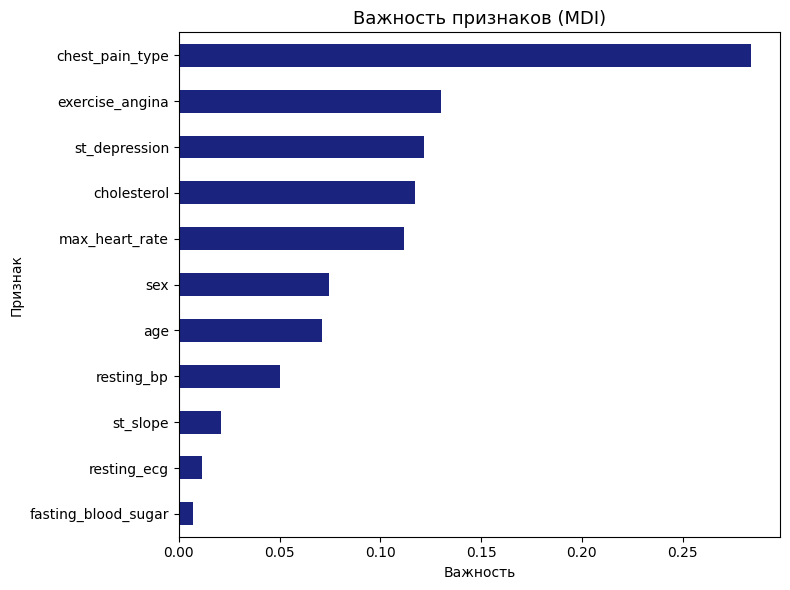

In [ ]:
rf_model = best_pipeline.named_steps['model']
feature_names = numerical_cols + categorical_cols

mdi_importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
mdi_importances.plot(kind='barh', ax=ax, color=PRIMARY_COLOR)
ax.set_title('Важность признаков (MDI)', fontsize=13)
ax.set_xlabel('Важность')
ax.set_ylabel('Признак')
plt.tight_layout()
plt.show()

**Интерпретация MDI:**
- **`chest_pain_type` (~0.28)** — наиболее важный признак, что полностью
  согласуется с результатами EDA и структурой дерева решений в Задании 2
- **`exercise_angina` (~0.13)** и **`st_depression` (~0.12)** — прямые
  клинические индикаторы ишемии миокарда, что обоснованно с медицинской точки зрения
- **`cholesterol` (~0.12)** — высокое значение требует осторожной
  интерпретации: холестерин является фактором риска ИБС в долгосрочной
  перспективе, но не прямым индикатором диагноза
- **`fasting_blood_sugar` (~0.01)** — наименее важный признак,
  что согласуется с низкой корреляцией, обнаруженной в EDA

**Ограничение MDI:** метод склонен к переоценке важности признаков
с высоким числом уникальных значений и вычисляется на обучающих данных,
что может не отражать реальную важность на новых данных.

### **4.2 Глобальная интерпретация — Permutation Importance** <a class="anchor" id="section4-2"></a>

**Permutation Importance** вычисляется на **тестовой** выборке путём
случайного перемешивания значений одного признака и измерения снижения
Recall. Если перемешивание признака существенно снижает качество модели,
признак считается важным. Процедура повторяется `n_repeats=10` раз
для получения устойчивой оценки.

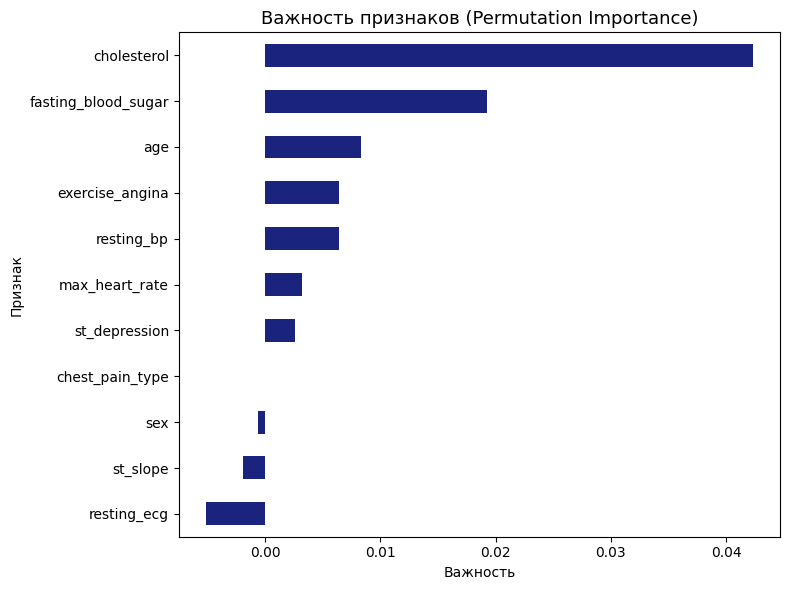

In [ ]:
perm_importance = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    scoring='recall',
    n_repeats=10,
    random_state=RANDOM_STATE
)

perm_importances = pd.Series(
    perm_importance.importances_mean,
    index=feature_names
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
perm_importances.plot(kind='barh', ax=ax, color=PRIMARY_COLOR)
ax.set_title('Важность признаков (Permutation Importance)', fontsize=13)
ax.set_xlabel('Важность')
ax.set_ylabel('Признак')
plt.tight_layout()
plt.show()

**Интерпретация Permutation Importance:**
- **`cholesterol` (~0.042)** — занял первое место, что существенно
  расходится с MDI. С медицинской точки зрения это требует осторожности:
  холестерин является фактором риска, но не прямым диагностическим маркером
- **`chest_pain_type` (~0.00)** — почти нулевая важность, хотя в MDI
  этот признак был наиболее значимым. Вероятная причина: высокая
  корреляция с другими признаками — модель компенсирует его отсутствие
- **Отрицательные значения** (`resting_ecg`, `st_slope`, `sex`) —
  перемешивание этих признаков незначительно повышает Recall, что
  указывает на возможное добавление шума в предсказания

**Вывод:** расхождение MDI и Permutation Importance подчёркивает
необходимость использования нескольких методов интерпретации одновременно.
Ни один метод не даёт исчерпывающей картины в отдельности.

### **4.3 Глобальная интерпретация — SHAP Summary Plot** <a class="anchor" id="section4-3"></a>

**SHAP (SHapley Additive exPlanations)** основан на теории игр Шепли
и вычисляет вклад каждого признака в отклонение предсказания от
среднего. В отличие от MDI и Permutation Importance, SHAP показывает
не только **величину** важности, но и **направление** влияния:
как именно конкретные значения признака влияют на предсказание модели.

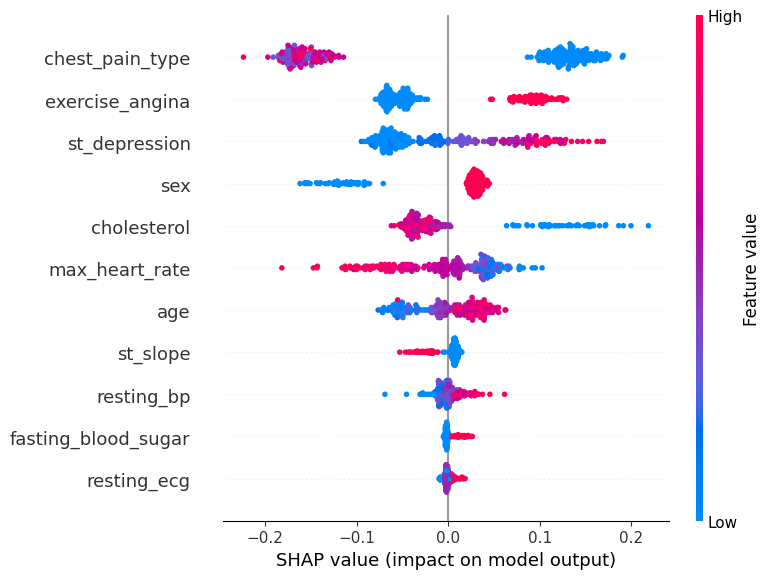

In [ ]:
X_test_transformed = best_pipeline.named_steps[
    'preprocessor'
].transform(X_test)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values[:, :, 1],
    X_test_transformed,
    feature_names=feature_names,
    show=True
)

**Интерпретация SHAP Summary Plot:**

Каждая точка — один пациент. Цвет отражает значение признака
(красный = высокое, синий = низкое). Позиция по оси X показывает
влияние на вероятность ИБС (положительное = в сторону ИБС).

- **`chest_pain_type`** — низкие значения (синий, тип асимптоматической
  боли) сильно смещают предсказание в сторону ИБС. Это парадоксально
  с клинической точки зрения, однако известно, что асимптоматическая
  стенокардия чаще всего ассоциируется с тяжёлой ИБС
- **`exercise_angina`** — высокие значения (красный, наличие стенокардии
  при нагрузке) смещают предсказание вправо (ИБС), что полностью
  соответствует клинической картине
- **`st_depression`** — высокие значения увеличивают вероятность ИБС;
  депрессия сегмента ST является классическим признаком ишемии
- **`max_heart_rate`** — низкая максимальная ЧСС при нагрузке
  (синий) ассоциируется с ИБС, что согласуется с медицинскими данными

**SHAP подтверждает MDI** по трём ключевым признакам и корректирует
Permutation Importance: `chest_pain_type` действительно важен, а
`cholesterol` имеет умеренное влияние, но не доминирующее.

### **4.4 Локальная интерпретация — SHAP Force Plot** <a class="anchor" id="section4-4"></a>

Force Plot объясняет предсказание для **конкретного пациента**.
Красные стрелки — признаки, толкающие предсказание в сторону ИБС;
синие — признаки, сдерживающие предсказание от ИБС.
Итоговое значение f(x) — вероятность ИБС по модели.

Пациент с ИБС:


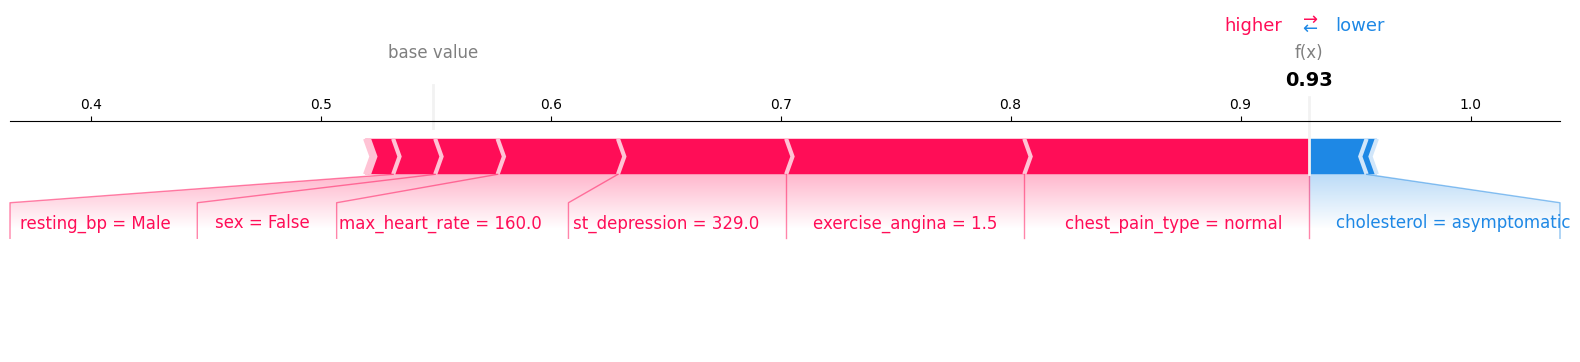

Пациент без ИБС:


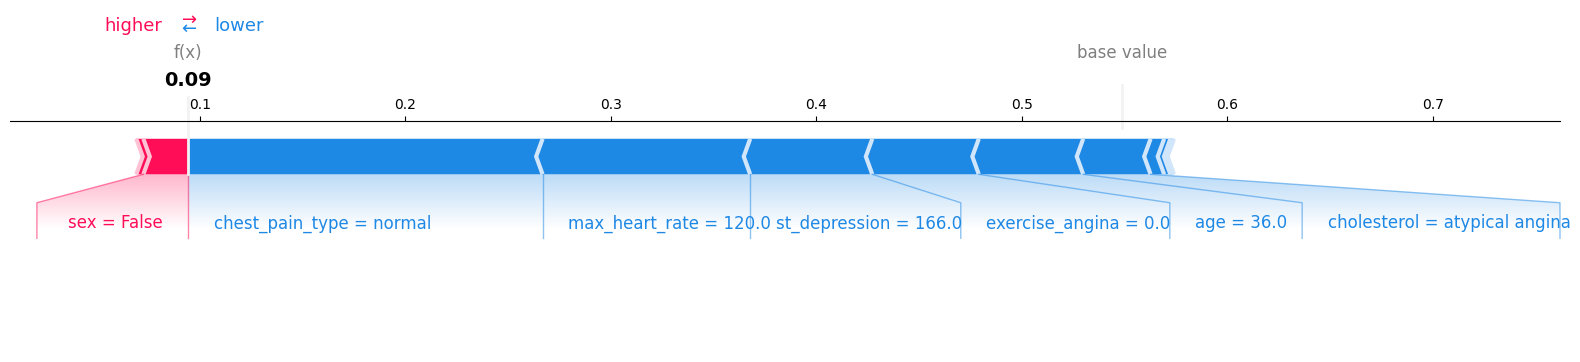

In [ ]:
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

idx_cad = y_test_reset[y_test_reset == 1].index[0]
idx_non_cad = y_test_reset[y_test_reset == 0].index[0]

X_test_transformed = best_pipeline.named_steps[
    'preprocessor'
].transform(X_test_reset)

# Force plot — пациент с ИБС
print("Пациент с ИБС:")
shap.force_plot(
    explainer.expected_value[1],
    shap_values[idx_cad, :, 1],
    X_test_reset.iloc[idx_cad],
    feature_names=feature_names,
    matplotlib=True
)
plt.show()

# Force plot — пациент без ИБС
print("Пациент без ИБС:")
shap.force_plot(
    explainer.expected_value[1],
    shap_values[idx_non_cad, :, 1],
    X_test_reset.iloc[idx_non_cad],
    feature_names=feature_names,
    matplotlib=True
)
plt.show()

**Интерпретация Force Plot:**

**Пациент с ИБС (f(x) = 0.93):**
Модель предсказывает ИБС с вероятностью 93%. Ключевые факторы,
толкающие предсказание в сторону ИБС: наличие `exercise_angina`,
высокий `st_depression`, `max_heart_rate` и `chest_pain_type`.
Единственный сдерживающий фактор (`cholesterol`) недостаточен
для изменения итогового предсказания.

**Пациент без ИБС (f(x) = 0.09):**
Модель предсказывает отсутствие ИБС с вероятностью 91%.
Решающими факторами являются: нормальный `chest_pain_type`,
отсутствие `exercise_angina`, умеренный `st_depression`,
молодой возраст (`age = 36`). Единственный фактор риска
(`sex`) не перевешивает совокупность защитных признаков.

**Клинический вывод:** модель принимает решения, согласующиеся
с клинической логикой — она учитывает совокупность признаков,
а не один изолированный показатель, что является важным
требованием для медицинского инструмента поддержки решений.

### **4.5 Итоги** <a class="anchor" id="section4-5"></a>

- Применены три метода глобальной интерпретации: MDI, Permutation
  Importance, SHAP — каждый даёт частичную картину, и только их
  совокупность позволяет сделать надёжные выводы
- **MDI и SHAP сходятся**: `chest_pain_type`, `exercise_angina`,
  `st_depression` — наиболее важные признаки, что полностью
  соответствует медицинским знаниям об ИБС
- **Permutation Importance** выявил `cholesterol` как ведущий признак,
  что расходится с MDI и SHAP; это объясняется корреляцией между
  признаками и не меняет общей клинической интерпретации
- SHAP force_plot подтвердил интерпретацию на уровне отдельных пациентов:
  модель принимает клинически обоснованные решения
- Признаки `fasting_blood_sugar` и `resting_ecg` имеют минимальный
  вклад во всех трёх методах

---

## 5. **Выводы** <a class="anchor" id="section5"></a>

В заключительном разделе подводятся итоги всей работы в рамках Задания 3.



In [ ]:
print(f"Датасет:       920 пациентов, 11 признаков")
print(f"Train/Test:    644 / 276 пациентов (70/30)")
print(f"Модель:        Random Forest (max_depth=5, n_estimators=90)")
print(f"")
print(f"{'Метрика':<12} {'Задание 2':>12} {'Задание 3':>12} {'Прирост':>10}")
print("-" * 50)
print(f"{'Recall':<12} {0.75:>12.2f} {recall_best:>12.2f} {recall_best - 0.75:>+10.2f}")
print(f"{'F1-Score':<12} {0.77:>12.2f} {f1_best:>12.2f} {f1_best - 0.77:>+10.2f}")
print(f"{'ROC-AUC':<12} {0.75:>12.2f} {roc_auc_best:>12.2f} {roc_auc_best - 0.75:>+10.2f}")

Датасет:       920 пациентов, 11 признаков
Train/Test:    644 / 276 пациентов (70/30)
Модель:        Random Forest (max_depth=5, n_estimators=90)

Метрика         Задание 2    Задание 3    Прирост
--------------------------------------------------
Recall               0.75         0.82      +0.07
F1-Score             0.77         0.83      +0.06
ROC-AUC              0.75         0.81      +0.06


### **Основные выводы:**

**Моделирование:**
- Построена и оценена продвинутая модель Random Forest в составе
  sklearn Pipeline с корректной предобработкой данных
- GridSearchCV с 5-кратной кросс-валидацией определил оптимальные
  гиперпараметры: `max_depth=5`, `n_estimators=90`
- Финальная модель достигла **Recall = 0.82** — на 7 п.п. выше бейзлайна
  Задания 2 (0.75), что означает на 7 из 100 больных пациентов больше
  получат направление на ангиографию и необходимое лечение
- Переобучение устранено: `max_depth=5` обеспечивает контролируемую
  сложность модели в отличие от неограниченного дерева в Задании 2

**Интерпретация:**
- Три метода анализа важности признаков (MDI, Permutation Importance,
  SHAP) совместно подтвердили клиническую обоснованность модели
- Наиболее предсказательные признаки — `chest_pain_type`,
  `exercise_angina`, `st_depression` — являются прямыми клиническими
  индикаторами ишемии миокарда
- SHAP force_plot показал, что модель принимает решения на основе
  совокупности признаков, а не изолированных показателей

**Ограничения и перспективы:**
- Удалены два клинически важных признака (`num_major_vessels`, `thal`)
  из-за критического уровня пропусков (>50%) — применение продвинутых
  методов импутации потенциально улучшит качество
- Recall = 0.82 означает, что 18% пациентов с ИБС по-прежнему
  остаются необнаруженными — для клинического применения
  может потребоваться дополнительная настройка порога классификации
- Модель может служить инструментом первичного скрининга ИБС,
  направляя на инвазивную ангиографию только пациентов с высоким
  риском, что снижает медицинские и финансовые затраты